## IMPORTING LIBRARIES

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go


## TO KNOW WHERE THE EXCEL FILE IS LOCATED

In [6]:
import os
os.getcwd()

'C:\\Users\\julie\\Downloads\\Data Analysis Final Project\\Python'

## CHECKING IF THE DATASET IS INSIDE THE PYTHON FOLDER

In [7]:
os.listdir()

['.ipynb_checkpoints', 'Employee Dataset.xlsx', 'Python Project.ipynb']

## IMPORTING THE EXCEL DATASET

In [8]:
df = pd.read_excel("Employee Dataset.xlsx")

## EXPLORATORY DATA ANALYSIS (EDA) AND DESCRIPTIVE STATISTICS

In [9]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [10]:
df.tail()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
1994,Business Analyst,1,PhD,7,Technology,Medium,Netherlands,Hybrid,1,100944
1995,AI Engineer,8,Diploma,1,Telecom,Startup,Australia,No,4,123566
1996,Product Manager,16,High School,8,Government,Startup,Netherlands,Hybrid,1,117104
1997,AI Engineer,20,Bachelor,13,Healthcare,Medium,USA,Yes,3,255356
1998,Machine Learning Engineer,2,Master,18,Technology,Enterprise,Remote,Yes,1,173635


In [11]:
df.shape

(1999, 10)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1999 entries, 0 to 1998
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   job_title         1999 non-null   str  
 1   experience_years  1999 non-null   int64
 2   education_level   1999 non-null   str  
 3   skills_count      1999 non-null   int64
 4   industry          1999 non-null   str  
 5   company_size      1999 non-null   str  
 6   location          1999 non-null   str  
 7   remote_work       1999 non-null   str  
 8   certifications    1999 non-null   int64
 9   salary            1999 non-null   int64
dtypes: int64(4), str(6)
memory usage: 251.8 KB


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.describe()

,experience_years,skills_count,certifications,salary
count,1999.000000,1999.000000,1999.000000,1999.000000
mean,9.877939,9.953477,2.474237,145606.454727
std,6.116741,5.414208,1.696788,36263.992744
min,0.000000,1.000000,0.000000,41404.000000
25%,5.000000,5.000000,1.000000,119497.000000
50%,10.000000,10.000000,2.000000,144185.000000
75%,15.000000,15.000000,4.000000,168211.500000
max,20.000000,19.000000,5.000000,292855.000000


In [15]:
df.nunique()

job_title             12
experience_years      21
education_level        5
skills_count          19
industry              10
company_size           5
location              10
remote_work            3
certifications         6
salary              1988
dtype: int64

In [16]:
df["education_level"].unique()

<ArrowStringArray>
['Bachelor', 'PhD', 'High School', 'Diploma', 'Master']
Length: 5, dtype: str

In [17]:
df["remote_work"].unique()

<ArrowStringArray>
['Hybrid', 'No', 'Yes']
Length: 3, dtype: str

In [18]:
df.select_dtypes(include="str").columns

Index(['job_title', 'education_level', 'industry', 'company_size', 'location',
       'remote_work'],
      dtype='str')

In [19]:
df["company_size"].unique()

<ArrowStringArray>
['Medium', 'Small', 'Large', 'Enterprise', 'Startup']
Length: 5, dtype: str

In [20]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [21]:
df["job_title"].value_counts()

job_title
Data Scientist               191
Cybersecurity Analyst        178
Machine Learning Engineer    176
Backend Developer            172
Business Analyst             171
Product Manager              169
AI Engineer                  162
DevOps Engineer              161
Cloud Engineer               161
Software Engineer            157
Frontend Developer           152
Data Analyst                 149
Name: count, dtype: int64

In [23]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


## DATA CLEANING 

In [24]:
df["salary"] = df["salary"].astype(float)

In [25]:
 df["salary"].dtype

dtype('float64')

## CALCULATED COLUMNS

## Salary Category

In [26]:
df["salary_category"] = np.where(df["salary"] >= 150000,"High", "Low")

In [27]:
df[["salary","salary_category"]].head()

,salary,salary_category
0,109413.0,Low
1,93764.0,Low
2,148123.0,Low
3,189123.0,High
4,165069.0,High


## EXPERIENCE CATEGORY

In [28]:
conditions = [
    df["experience_years"] <= 5,
    df["experience_years"] <= 10,
] 
choices = ["Junior", "Mid-Level"]
df["experience_category"] = np.select(
    conditions, 
    choices, 
    default = "Senior"
)

In [29]:
df[["experience_years", "experience_category"]].head()

,experience_years,experience_category
0,10,Mid-Level
1,5,Junior
2,18,Senior
3,19,Senior
4,15,Senior


## SALARY PER EXPERIENCE

In [30]:
df["salary_per_experience"] =np.where(
    df["experience_years"] > 0,
    df["salary"] /
df["experience_years"],
    df["salary"]
)

In [31]:
df[["salary","experience_years", "salary_per_experience"]].head()

,salary,experience_years,salary_per_experience
0,109413.0,10,10941.300000
1,93764.0,5,18752.800000
2,148123.0,18,8229.055556
3,189123.0,19,9953.842105
4,165069.0,15,11004.600000


## CORRELATION ANALYSIS

In [32]:
correlation = df[["experience_years", "skills_count", "certifications", "salary"]].corr()

In [33]:
correlation

,experience_years,skills_count,certifications,salary
experience_years,1.000000,-0.028433,0.041169,0.410915
skills_count,-0.028433,1.000000,-0.017156,0.134619
certifications,0.041169,-0.017156,1.000000,0.128401
salary,0.410915,0.134619,0.128401,1.000000


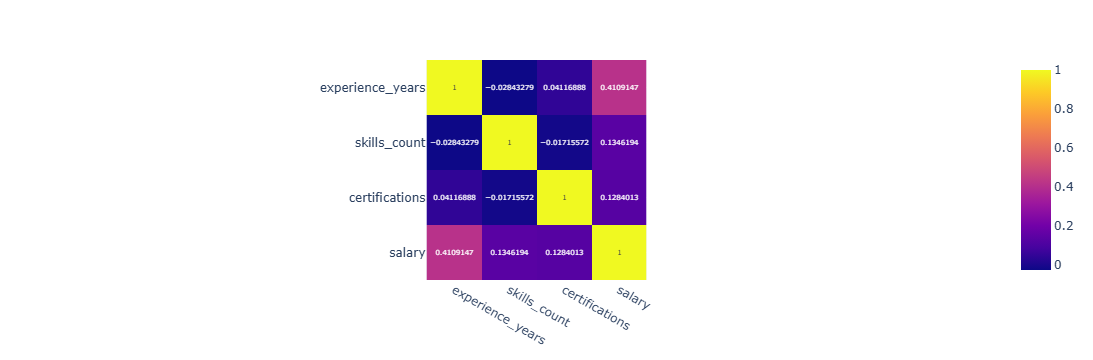

In [34]:
fig = px.imshow(correlation,
text_auto=True)
fig.show()

## SORTING AND FILTERING DATA

## Sorting Salary from Highest to Lowest

In [35]:
df.sort_values("salary",ascending=False).head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,salary_category,experience_category,salary_per_experience
951,Cloud Engineer,20,PhD,16,Finance,Enterprise,USA,No,4,292855.0,High,Senior,14642.750000
1083,Cybersecurity Analyst,14,PhD,11,Government,Enterprise,USA,Yes,5,275896.0,High,Senior,19706.857143
536,Machine Learning Engineer,18,PhD,4,Consulting,Enterprise,Canada,No,4,271175.0,High,Senior,15065.277778
638,AI Engineer,17,Diploma,10,Consulting,Enterprise,USA,Yes,5,268299.0,High,Senior,15782.294118
628,AI Engineer,18,Diploma,14,Government,Large,USA,Yes,2,260034.0,High,Senior,14446.333333


## Sorting Experience Years From Lowest to Highest

In [36]:
df.sort_values("experience_years",ascending=True).head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,salary_category,experience_category,salary_per_experience
1290,Data Scientist,0,PhD,13,Finance,Medium,India,No,0,86811.0,Low,Junior,86811.0
1111,Machine Learning Engineer,0,Master,6,Consulting,Large,Singapore,Hybrid,4,143683.0,Low,Junior,143683.0
342,AI Engineer,0,PhD,7,Media,Small,Sweden,Hybrid,2,139524.0,Low,Junior,139524.0
1669,Cloud Engineer,0,High School,18,Education,Startup,Germany,Hybrid,0,101447.0,Low,Junior,101447.0
115,Frontend Developer,0,Diploma,1,Retail,Enterprise,Canada,Yes,1,128777.0,Low,Junior,128777.0


## Filtering High Salary Employees

In [37]:
df[df["salary_category"]=="High"].head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,salary_category,experience_category,salary_per_experience
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123.0,High,Senior,9953.842105
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069.0,High,Senior,11004.600000
5,AI Engineer,0,High School,4,Education,Enterprise,USA,No,2,180351.0,High,Junior,180351.000000
6,Backend Developer,6,High School,16,Manufacturing,Enterprise,Canada,No,3,165375.0,High,Mid-Level,27562.500000
7,Machine Learning Engineer,4,Bachelor,18,Healthcare,Enterprise,Canada,Hybrid,5,202463.0,High,Junior,50615.750000


## Filtering Employees With More Than 10 or More Years of Experience

In [38]:
df[df["experience_years"]>=10].head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,salary_category,experience_category,salary_per_experience
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413.0,Low,Mid-Level,10941.300000
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123.0,Low,Senior,8229.055556
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123.0,High,Senior,9953.842105
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069.0,High,Senior,11004.600000
9,Frontend Developer,18,PhD,2,Retail,Enterprise,India,Hybrid,5,128377.0,Low,Senior,7132.055556


## Filtering People Who Work Remotely

In [39]:
df[df["remote_work"]=="Yes"].head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,salary_category,experience_category,salary_per_experience
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123.0,High,Senior,9953.842105
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069.0,High,Senior,11004.600000
8,AI Engineer,5,Diploma,14,Telecom,Enterprise,Singapore,Yes,0,171834.0,High,Junior,34366.800000
10,Frontend Developer,1,High School,10,Healthcare,Large,Netherlands,Yes,5,105755.0,Low,Junior,105755.000000
11,Business Analyst,19,Master,7,Finance,Large,Netherlands,Yes,5,157417.0,High,Senior,8285.105263


## INDEX FILTER OPERATION

## Selecting First Row

In [40]:
df.iloc[0]

job_title                AI Engineer
experience_years                  10
education_level             Bachelor
skills_count                       2
industry                  Healthcare
company_size                  Medium
location                       India
remote_work                   Hybrid
certifications                     2
salary                      109413.0
salary_category                  Low
experience_category        Mid-Level
salary_per_experience        10941.3
Name: 0, dtype: object

## Selecting the First Five Rows

In [41]:
df.iloc[0:5]

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,salary_category,experience_category,salary_per_experience
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413.0,Low,Mid-Level,10941.300000
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764.0,Low,Junior,18752.800000
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123.0,Low,Senior,8229.055556
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123.0,High,Senior,9953.842105
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069.0,High,Senior,11004.600000


## Selecting Specific Rows

In [42]:
df.iloc[[6,8,10]]

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,salary_category,experience_category,salary_per_experience
6,Backend Developer,6,High School,16,Manufacturing,Enterprise,Canada,No,3,165375.0,High,Mid-Level,27562.5
8,AI Engineer,5,Diploma,14,Telecom,Enterprise,Singapore,Yes,0,171834.0,High,Junior,34366.8
10,Frontend Developer,1,High School,10,Healthcare,Large,Netherlands,Yes,5,105755.0,Low,Junior,105755.0


## Select Index Positions 9 and 10

In [43]:
df.iloc[9:11]

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,salary_category,experience_category,salary_per_experience
9,Frontend Developer,18,PhD,2,Retail,Enterprise,India,Hybrid,5,128377.0,Low,Senior,7132.055556
10,Frontend Developer,1,High School,10,Healthcare,Large,Netherlands,Yes,5,105755.0,Low,Junior,105755.000000


## Selecting the First Five Rows and Three Columns

In [44]:
df.iloc[0:5,0:4]

,job_title,experience_years,education_level,skills_count
0,AI Engineer,10,Bachelor,2
1,Data Analyst,5,Bachelor,17
2,Frontend Developer,18,PhD,4
3,Business Analyst,19,PhD,13
4,Product Manager,15,Bachelor,7


## Selecting Specific Rows and Columns

In [45]:
df.iloc[[13,14,15],[5,6,7]]

,company_size,location,remote_work
13,Startup,Singapore,Yes
14,Enterprise,India,No
15,Medium,Remote,No


## Selecting the Last Four Rows and Last Three Columns

In [46]:
df.iloc[-4:,-3:]

,salary_category,experience_category,salary_per_experience
1995,Low,Mid-Level,15445.75
1996,Low,Senior,7319.00
1997,High,Senior,12767.80
1998,High,Junior,86817.50


## PLOTLY VISUALIZATION

In [47]:
job_counts = df["job_title"].value_counts().reset_index()
job_counts.columns = ["job_title","employee_count"]

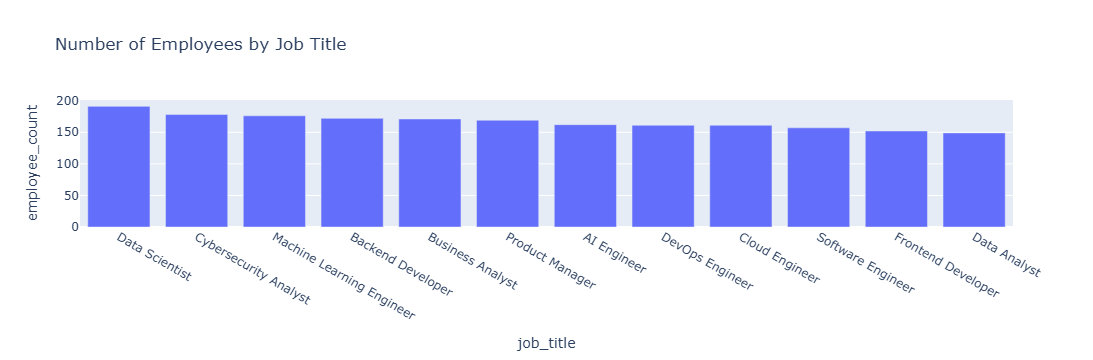

In [48]:
fig = px.bar(
    job_counts,
    x="job_title",
    y="employee_count",
    title="Number of Employees by Job Title"
)
fig.show()

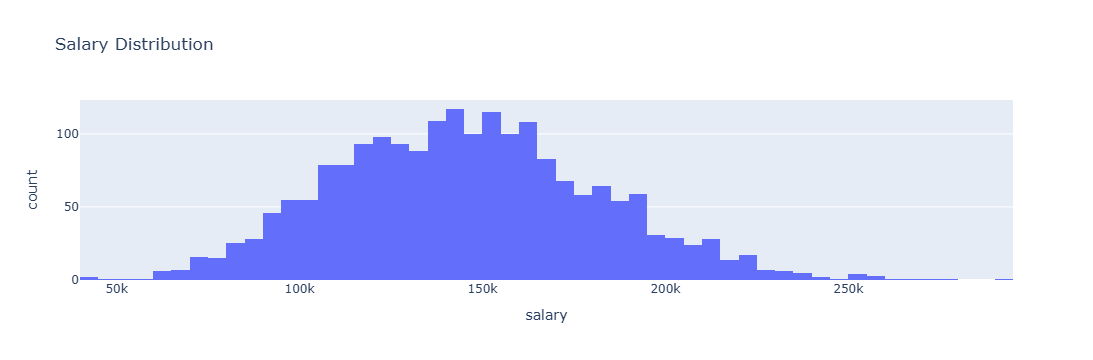

In [49]:
fig = px.histogram(
      df,
      x = "salary",
     title = "Salary Distribution"
)
fig.show()

## Calculation of Average Salary by Education Level

In [50]:
education_salary = df.groupby("education_level")["salary"].mean().reset_index()

In [51]:
education_salary

,education_level,salary
0,Bachelor,141269.354922
1,Diploma,140441.747017
2,High School,131772.387409
3,Master,153367.529563
4,PhD,162271.109694


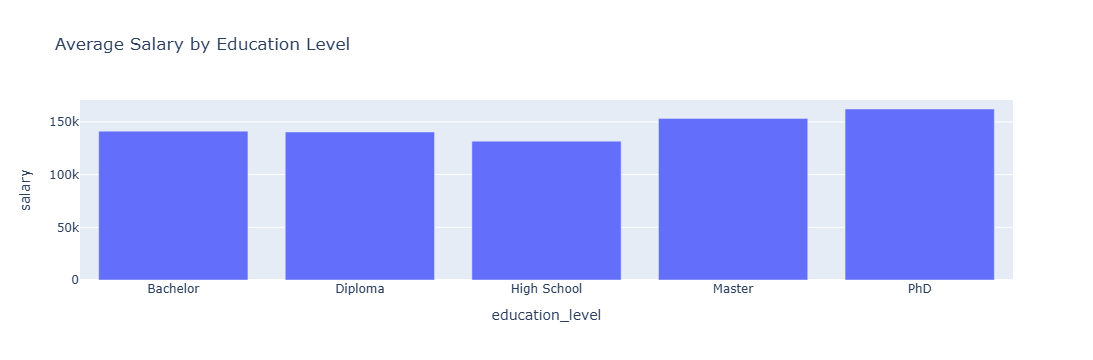

In [52]:
fig = px.bar(
    education_salary,
    x="education_level",
    y="salary",
    title="Average Salary by Education Level"
)
fig.show()

## Calculation of Average Salary by Industry

In [53]:
industry_salary = df.groupby("industry")["salary"].mean().reset_index()
industry_salary

,industry,salary
0,Consulting,144182.280000
1,Education,144754.242574
2,Finance,144550.015306
3,Government,143450.240838
4,Healthcare,146729.925743
5,Manufacturing,148886.857143
6,Media,144923.255208
7,Retail,146168.564103
8,Technology,146620.875000
9,Telecom,145546.406393


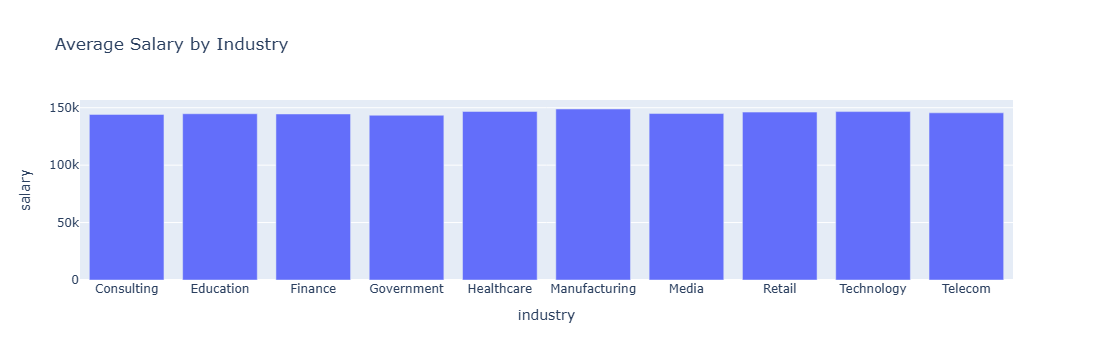

In [54]:
fig = px.bar(
    industry_salary,
    x="industry",
    y="salary",
    title="Average Salary by Industry"
)
fig.show()

## Calculation of Counts of Remote Workers

In [55]:
remote_counts = df["remote_work"].value_counts().reset_index()
remote_counts.columns = ["remote_work","employee_count"]

In [56]:
remote_counts

,remote_work,employee_count
0,Hybrid,706
1,No,653
2,Yes,640


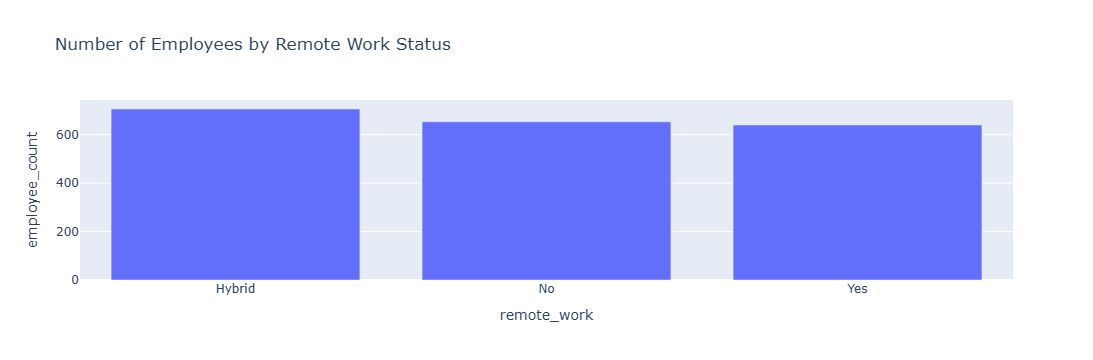

In [57]:
fig = px.bar(
    remote_counts,
    x="remote_work",
    y="employee_count",
    title="Number of Employees by Remote Work Status"
)
fig.show()

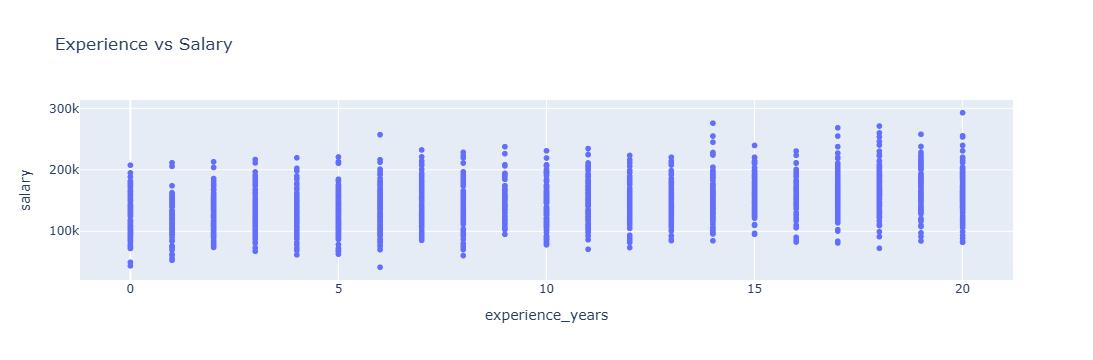

In [58]:
fig = px.scatter(
    df,
    x="experience_years",
    y="salary",
    title="Experience vs Salary"
)
fig.show()

## CREATING THE DASHBOARD

In [59]:
from plotly.subplots import make_subplots

In [60]:
dashboard = make_subplots(rows = 3, cols = 2,
        subplot_titles = ("Employee by Job Title",
                          "Salary Distribution",
                          "Averaage Salary by Education",
                          "Average Salary by Industry",
                          "Employees by Remote Work",
                          "Experiece vs Salary"))
                          
                          

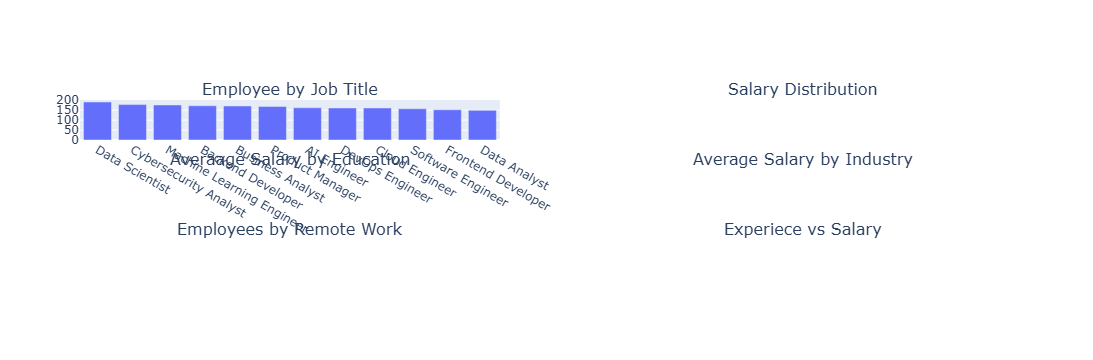

In [61]:
dashboard.add_trace(go.Bar(
    x=job_counts["job_title"],
    y=job_counts["employee_count"]),
    row=1,
    col=1)

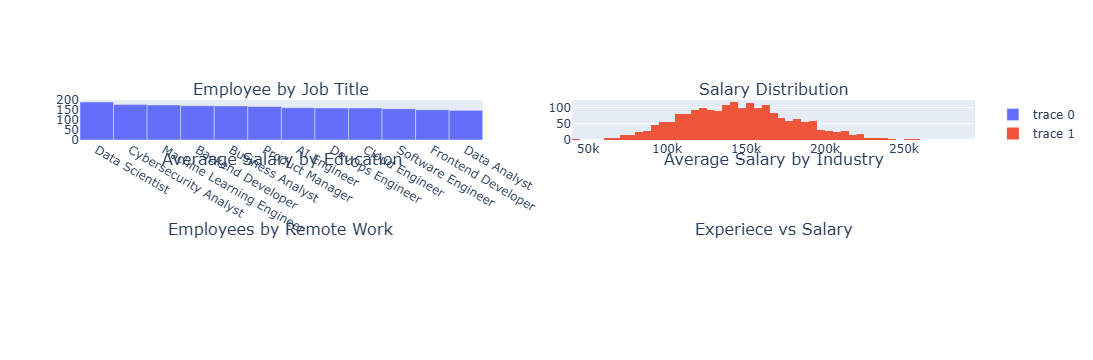

In [62]:
dashboard.add_trace(go.Histogram(
    x=df["salary"]),
    row=1,
    col=2)

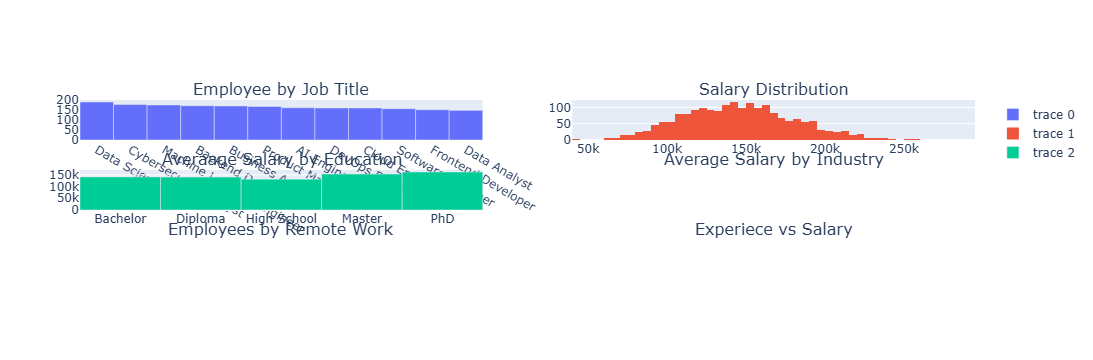

In [63]:
dashboard.add_trace(go.Bar(
    x=education_salary["education_level"],
    y=education_salary["salary"]),
    row=2,
    col=1)

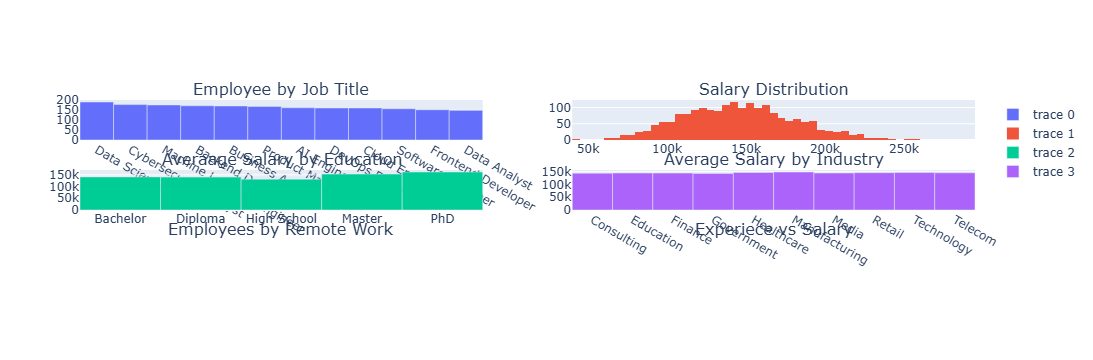

In [64]:
dashboard.add_trace(go.Bar(
    x=industry_salary["industry"],
    y=industry_salary["salary"]),
    row=2,
    col=2)

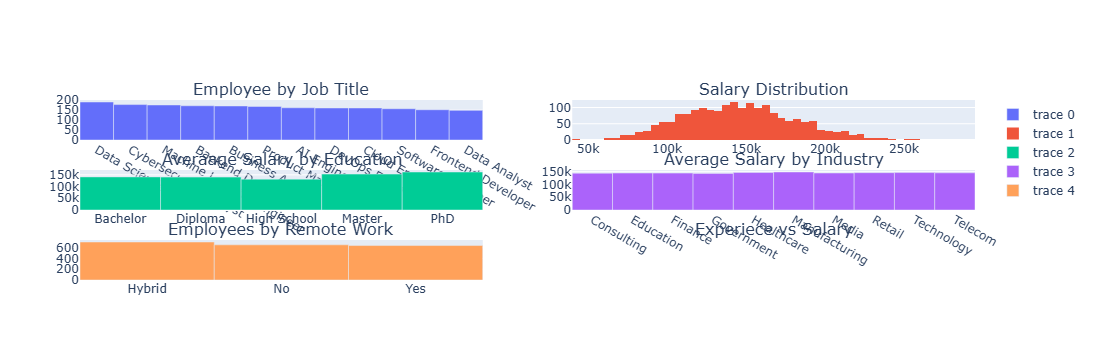

In [65]:
dashboard.add_trace(go.Bar(
    x=remote_counts["remote_work"],
    y=remote_counts["employee_count"]),
    row=3,
    col=1)

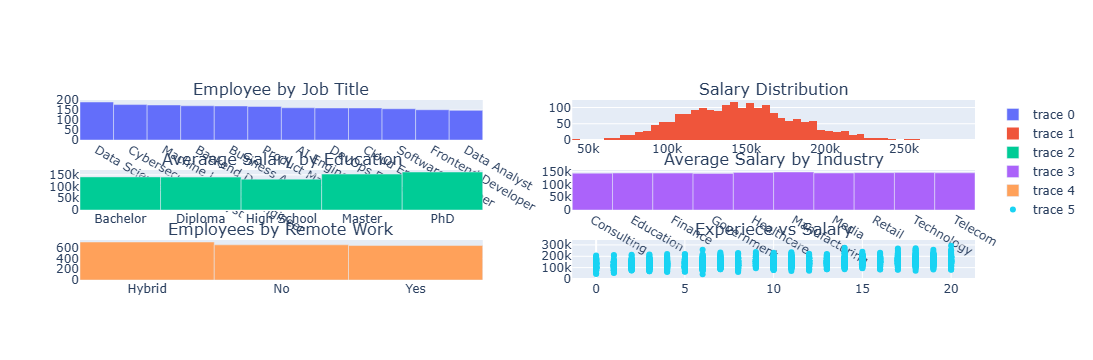

In [66]:
dashboard.add_trace(go.Scatter(
    x=df["experience_years"],
    y=df["salary"],
    mode="markers"),
    row=3,
    col=2)

## Arranging Dashboard Layout

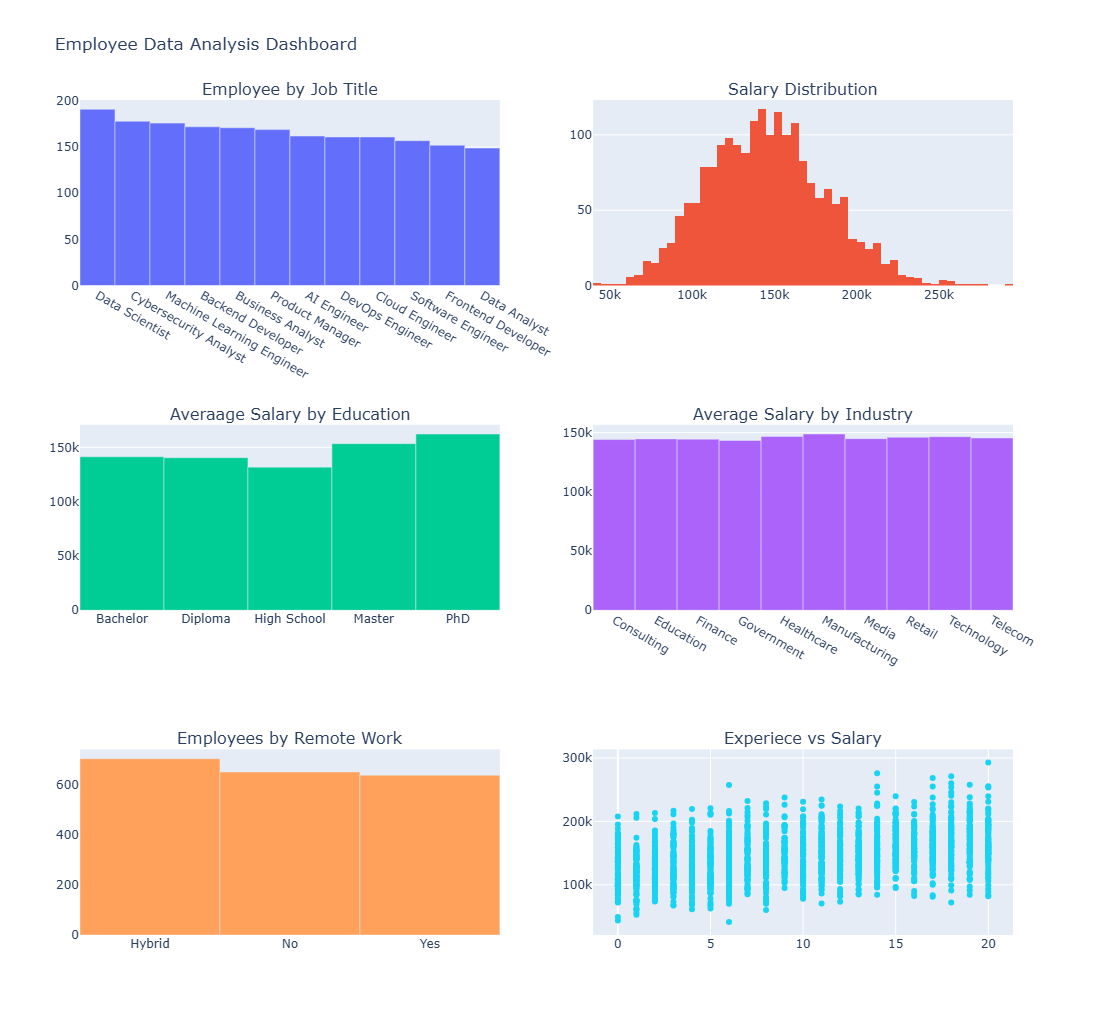

In [67]:
dashboard.update_layout(
    height=1000,
    width=1200,
    title_text="Employee Data Analysis Dashboard",
    showlegend=False)
dashboard.show()
    

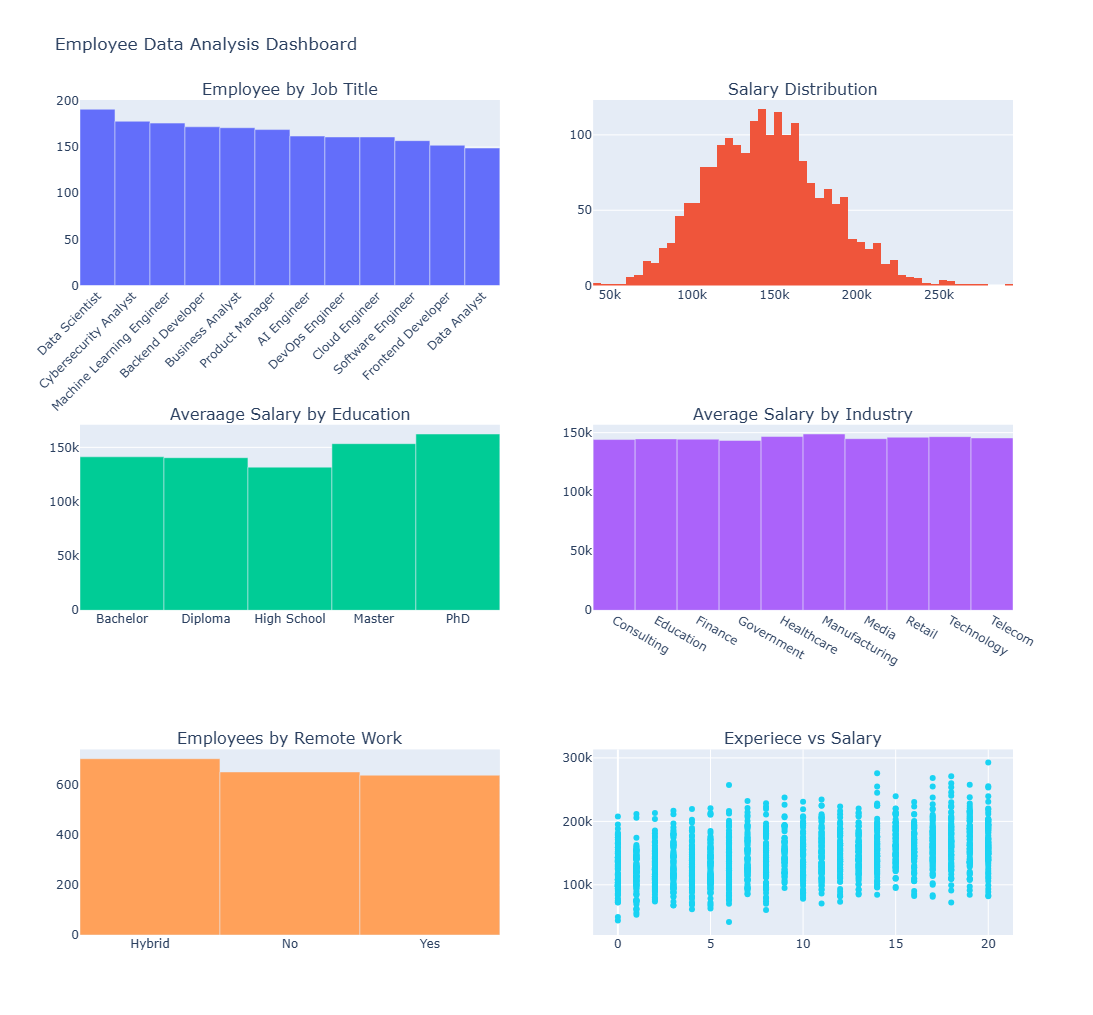

In [68]:
dashboard.update_xaxes(
    tickangle=-45,
    row=1,
    col=1)
dashboard.show()

## IMPORTING LOGISTIC REGRESSION LIBRARIES

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Choosing x and y Variables

In [70]:
x = df[["experience_years","skills_count","certifications"]]
y = df["salary_category"]

In [71]:
x.head()

,experience_years,skills_count,certifications
0,10,2,2
1,5,17,0
2,18,4,1
3,19,13,0
4,15,7,0


In [72]:
y.head()

0     Low
1     Low
2     Low
3    High
4    High
Name: salary_category, dtype: str

## Spliting the Data into Trianing and Testing

In [73]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42)

## Creating the Logistic Regression Model

In [74]:
model = LogisticRegression()

In [75]:
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

## Letting the Model Making Prediction

In [76]:
y_pred = model.predict(x_test)

## Checking the Model Accuracy

In [77]:
accuracy = accuracy_score(y_test,y_pred)
accuracy

0.68

## Report classification

In [78]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

        High       0.66      0.60      0.63       182
         Low       0.69      0.75      0.72       218

    accuracy                           0.68       400
   macro avg       0.68      0.67      0.67       400
weighted avg       0.68      0.68      0.68       400



## Confusion Matrix

In [80]:
cm = confusion_matrix(y_test,y_pred)
cm

array([[109,  73],
       [ 55, 163]])